# Importing Libraries, install PyQt for visualisations

In [12]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
import mne
from mne.io import read_raw_brainvision

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# Set interactive backend for figures
%matplotlib qt6
mne.viz.set_browser_backend("qt")

'qt'

# Importing Data

In [2]:
current_dir = Path.cwd()
vhdr_path = current_dir / "Oddball_Experiment" / "Data" / "Oddball.vhdr"
# raw data (preload=True loads samples into RAM for fast filtering/processing)
raw = mne.io.read_raw_brainvision(vhdr_path, preload=True)
raw

Extracting parameters from D:\Study\BTU University Subjects\BCI\MNE Python Tutorial\Oddball_Experiment\Data\Oddball.vhdr...
Setting channel info structure...
Reading 0 ... 687899  =      0.000 ...   687.899 secs...


<RawBrainVision | Oddball.eeg, 54 x 687900 (687.9 s), ~283.5 MiB, data loaded>

# Channel x Time Plot

In [3]:
# Open the interactive time-series browser showing all channels
raw.plot(
    n_channels=len(raw.ch_names),  # Show all channels simultaneously
    duration=10.0,                 # Window length in seconds
    scalings={'eeg':50e-6},               # scale channel amplitudes
    show_options=True,             # Display the settings panel (filters, scales)
    block=True                     # Keep the plot window open in standalone scripts
)

Channels marked as bad:
none


In [4]:
raw.get_data()

array([[ 0.0004634,  0.0004631,  0.0004562, ...,  0.0003623,  0.0003656,
         0.0003607],
       [ 0.0002409,  0.0002384,  0.0002352, ...,  0.0002073,  0.000208 ,
         0.0002009],
       [ 0.0002183,  0.0002164,  0.0002118, ...,  0.0001906,  0.000191 ,
         0.0001838],
       ...,
       [-0.00337  , -0.00337  , -0.00337  , ..., -0.00271  , -0.00271  ,
        -0.00271  ],
       [ 0.00139  ,  0.00138  ,  0.00137  , ...,  0.00273  ,  0.00273  ,
         0.00273  ],
       [-0.0015   , -0.00151  , -0.00151  , ..., -0.00067  , -0.00067  ,
        -0.00068  ]], shape=(54, 687900))

In [5]:
raw.get_data().shape

(54, 687900)

# Checking the channels types and changing the EOG channels type to 'eog'

In [6]:
# When you import an EEG file (like .edf, .bdf, or .vhdr), MNE attempts to infer what each channel contains based on the file header or channel names. In many cases, it defaults to labeling every recorded channel as generic 'eeg'.

# Check how many of each type MNE has assigned:
print(raw.get_channel_types())
# Or check a quick summary:
print(raw)  # Displays e.g. "<Raw | ... 60 EEG, 4 EOG, ...>"


['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
<RawBrainVision | Oddball.eeg, 54 x 687900 (687.9 s), ~283.5 MiB, data loaded>


In [7]:
# As you can see, all channels are of type EEG, now set these to 'eog' since these channels measure eye movements
raw.set_channel_types({
    'EOGv1': 'eog',
    'EOGv2': 'eog',
    'EOGh1': 'eog', 
    'EOGh2': 'eog'
})

<RawBrainVision | Oddball.eeg, 54 x 687900 (687.9 s), ~283.5 MiB, data loaded>

# Setting the channel locations on the scalp

In [8]:
print(raw.ch_names)

['Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO3', 'POz', 'PO4', 'O1', 'O2', 'EOGv1', 'EOGv2', 'EOGh1', 'EOGh2']


In [9]:
raw = raw.set_montage('biosemi64', match_case=False)
_ = raw.plot_sensors(show_names=True)

In [10]:
raw = raw.filter(l_freq=0.1, h_freq=None)
raw.plot(
    n_channels=len(raw.ch_names),  # Show all channels simultaneously
    duration=10.0,                 # Window length in seconds
    scalings="auto",        # Automatically scale channel amplitudes
    show_options=True,             # Display the settings panel (filters, scales)
    block=True                     # Keep the plot window open in standalone scripts
)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 33001 samples (33.001 s)

Channels marked as bad:
none


# ICA Decomposition

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 50 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 17.5s.


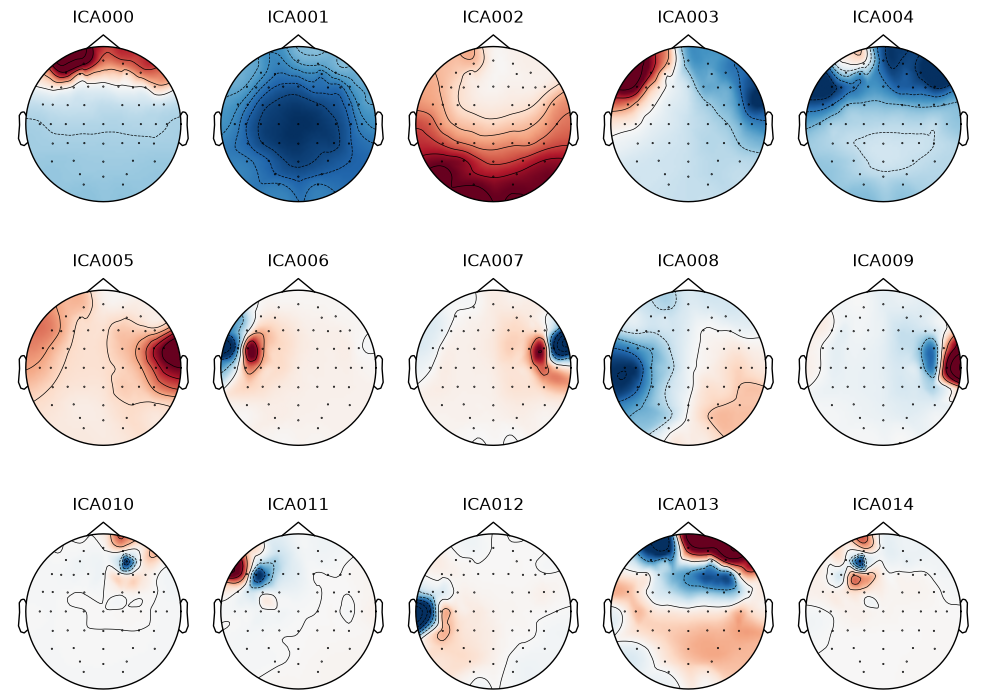

In [13]:
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=None)
ica = ICA(n_components=15)
ica = ica.fit(raw_filtered)
ica.plot_components()

In [ ]:
# Plots component activations over time alongside raw EEG
# Clicking a component's name on the left toggles it as an excluded artifact
ica.plot_sources(raw)

In [ ]:
# 1. Plot interactive topomaps (clicking a component opens its properties)
ica.plot_components(inst=raw_filtered)

# 2. Inspect specific components with spectrum + ERP image
# You can pass raw or epochs data to inspect
ica.plot_properties(raw_filtered, picks=None)  # Inspect ICs 0, 1, and 2

In [ ]:
## Since ICA Decomposition is Not Clear in Visualisations not using it...

# Removing EOG channels before epoching

In [14]:
# Exclude EOG channels
eog_chans = ['EOGv1', 'EOGv2', 'EOGh1', 'EOGh2']
eog_present = [ch for ch in eog_chans if ch in raw.ch_names]
if eog_present:
    raw.drop_channels(eog_present)

# Set standard 10-10 channel electrode montage
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, on_missing='ignore')

C:\Users\gokul\AppData\Local\Temp\ipykernel_5320\1242059817.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


<RawBrainVision | Oddball.eeg, 50 x 687900 (687.9 s), ~262.5 MiB, data loaded>

# Resampling and Filtering and Rereferencing

In [15]:
# Resample signal to 250 Hz
raw.resample(250)

# Bandpass filter between 1.0 Hz and 40.0 Hz
raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin')

# Re-reference channels to Common Average Reference (CAR)
raw.set_eeg_reference(ref_channels='average', projection=False)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawBrainVision | Oddball.eeg, 50 x 171975 (687.9 s), ~65.7 MiB, data loaded>

In [16]:
# Extract event triggers
events, event_dict = mne.events_from_annotations(raw)

# Identify target and standard triggers dynamically
std_keys = [k for k in event_dict.keys() if '1' in k]
tgt_keys = [k for k in event_dict.keys() if '2' in k]

selected_event_dict = {k: event_dict[k] for k in (std_keys + tgt_keys)}

# Extract epochs (-200 ms to 800 ms with baseline -200 to 0 ms)
tmin, tmax = -0.2, 0.8
baseline = (-0.2, 0)

epochs = mne.Epochs(
    raw,
    events=events,
    event_id=selected_event_dict,
    tmin=tmin,
    tmax=tmax,
    baseline=baseline,
    preload=True
)

epochs_std = epochs[std_keys]
epochs_tgt = epochs[tgt_keys]

Used Annotations descriptions: ['Stimulus/S  1', 'Stimulus/S  2', 'Stimulus/S 32']
Not setting metadata
601 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 601 events and 251 original time points ...
0 bad epochs dropped


In [17]:
# Compute averages and difference wave
evoked_std = epochs_std.average()
evoked_tgt = epochs_tgt.average()
evoked_diff = mne.combine_evoked([evoked_tgt, -evoked_std], weights='equal')

# Select channel Cz
cz_idx = raw.ch_names.index('Cz') if 'Cz' in raw.ch_names else 0
cz_name = raw.ch_names[cz_idx]
times_ms = epochs.times * 1000

# Plot ERPs[cite: 3]
plt.figure(figsize=(10, 5), facecolor='w')
plt.plot(times_ms, evoked_std.data[cz_idx] * 1e6, 'b-', label='Standard', linewidth=1.5)
plt.plot(times_ms, evoked_tgt.data[cz_idx] * 1e6, 'r-', label='Target', linewidth=1.8)
plt.plot(times_ms, evoked_diff.data[cz_idx] * 1e6, 'k--', label='Difference (Target - Standard)', linewidth=1.5)
plt.axhline(0, color='k', linestyle=':', alpha=0.5)
plt.axvline(0, color='k', linestyle=':', alpha=0.5)
plt.grid(True)
plt.xlabel('Time (ms)')
plt.ylabel(r'Amplitude ($\mu$V)')
plt.title(f'ERP Comparison at Channel {cz_name} (n_std={len(epochs_std)}, n_tgt={len(epochs_tgt)})')
plt.legend(loc='upper left')
plt.show()

# Feature Extraction (Windowed Means)

In [18]:
## Feature Extraction (Windowed Means)

# Define 9 window intervals (in seconds)
time_windows = [
    (0.15, 0.20), (0.20, 0.25), (0.25, 0.30), (0.30, 0.35),
    (0.35, 0.40), (0.40, 0.45), (0.45, 0.50), (0.50, 0.55), (0.55, 0.60)
]

def extract_windowed_means(epochs_obj, windows):
    data = epochs_obj.get_data(copy=True)  # Shape: (n_epochs, n_channels, n_times)
    times = epochs_obj.times
    features = []

    for t_start, t_end in windows:
        mask = (times >= t_start) & (times <= t_end)
        window_mean = data[:, :, mask].mean(axis=-1)
        features.append(window_mean)

    return np.hstack(features)

# Extract features X
X = extract_windowed_means(epochs, time_windows)

# Get numeric event codes for target stimuli
tgt_codes = [event_dict[k] for k in tgt_keys]

# Generate binary targets (1 for Target, 0 for Standard)
y = np.array([1 if code in tgt_codes else 0 for code in epochs.events[:, 2]])

# Train/Test Split & 10-Fold Cross-Validation

In [19]:
# 70/30 Sequential train/test split
n_samples = len(y)
split_idx = int(np.round(n_samples * 0.70))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 10-Fold Cross-Validation on Training Split
lda_cv = LinearDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(lda_cv, X_train, y_train, cv=cv, scoring='roc_auc')
cv_auc = np.mean(cv_scores)
cv_loss = 1 - cv_auc

print("\n==========================================")
print("--- 10-Fold Cross-Validation on Training Split ---")
print(f"CV Predictive Loss:                     {cv_loss:.4f}")
print(f"CV AUC Score:                          {cv_auc:.4f}")
print("==========================================")


--- 10-Fold Cross-Validation on Training Split ---
CV Predictive Loss:                     0.1466
CV AUC Score:                          0.8534


# Model Evaluation on Held-Out Test Set

In [20]:
# Fit model on training split
clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train)

# Evaluate on held-out test split
test_probs = clf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_loss = 1 - test_auc

print("\n==========================================")
print("--- Generalization on Held-Out Split ---")
print(f"Held-Out Test Predictive Loss:         {test_loss:.4f}")
print(f"Held-Out Test AUC Score:               {test_auc:.4f}")
print("==========================================")


--- Generalization on Held-Out Split ---
Held-Out Test Predictive Loss:         0.3107
Held-Out Test AUC Score:               0.6893
